<div align="center">

<p style="font-size:42px; margin-bottom:8px;">
    <strong><span style="color:#2563EB;">AI TalentScout</span></strong>
</p>

<p style="font-size:20px; color:#6B7280;">
    <strong>Intelligent Resume Screening &amp; Candidate Ranking System</strong>
</p>

</div>


## <strong><span style="color:#2563EB;">AI Resume Screening & Candidate Ranking System</span></strong>

An <strong>end-to-end Machine Learning application</strong> that predicts whether a <strong>job candidate</strong> should be <span style="background-color:#DDEBFF;"><strong>shortlisted</strong></span> based on <strong>resume-related information</strong> and <span style="background-color:#FFF3B0;"><strong>ranks candidates</strong></span> according to their <strong>predicted suitability score</strong>. The project includes <strong>data preprocessing</strong>, <strong>exploratory data analysis (EDA)</strong>, <strong>feature engineering</strong>, <strong>model comparison</strong>, <strong>model evaluation</strong>, and an <strong>interactive Streamlit web application</strong> for <strong>real-time predictions</strong> and <strong>candidate ranking</strong>.


## <strong><span style="color:#2563EB;">Use Case</span></strong>

Recruiters often receive <strong>hundreds of job applications</strong> for a single position. Manually reviewing every <strong>resume</strong> is <span style="background-color:#FFE4E6;"><strong>time-consuming</strong></span> and <span style="background-color:#FFE4E6;"><strong>inconsistent</strong></span>. This system helps <strong>recruiters</strong> by automatically <span style="background-color:#DDEBFF;"><strong>evaluating candidate profiles</strong></span>, <span style="background-color:#FFF3B0;"><strong>predicting their likelihood of being shortlisted</strong></span>, <strong>ranking applicants</strong> based on <strong>model confidence</strong>, and enabling <strong>faster</strong>, <strong>data-driven hiring decisions</strong>.


In [ ]:
#lets start 

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

Business Understanding
        ↓
Data Collection
        ↓
Dataset Understanding
        ↓
Data Cleaning 
        ↓
Handle Outliers (if required)
        ↓
Exploratory Data Analysis (EDA)
        ↓
Feature Engineering
        ↓
Encoding
        ↓
Define X and y
        ↓
Train-Test Split
        ↓
Feature Scaling (if required)
        ↓
(Optional) PCA / Feature Selection
        ↓
Train Multiple Models
        ↓
Cross Validation
        ↓
Hyperparameter Tuning
        ↓
Final Model Selection
        ↓
Evaluation on Test Set
        ↓
Save Model
        ↓
Deployment (Streamlit)
        ↓
GitHub + README

In [ ]:
data = pd.read_csv(r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\AI Resume Screening & Candidate Ranking System\dataset\resume_dataset_200k_enhanced.csv")


df = pd.DataFrame(data)

In [ ]:
#data understanding

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df['company_type'].value_counts()

In [ ]:
df.columns

In [17]:
df.shape

(200000, 17)

<h2 style="font-size:30px; color:#374151;">
    <strong>Target Variable</strong>
</h2>

<p>
In this dataset, the <strong><span style="color:#4F46E5;">Hired</span></strong> column represents the <span style="background-color:#FEF3C7; padding:2px 6px; border-radius:4px;"><strong>target variable</strong></span>.
</p>

<p>➦ <span style="background-color:#FFE4E6; padding:2px 6px; border-radius:4px;"><strong>0 = Not Hired</strong></span></p>

<p>➦ <span style="background-color:#DCFCE7; padding:2px 6px; border-radius:4px;"><strong>1 = Hired</strong></span></p>

<h2 style="font-size:30px; color:#374151;">
    <strong>Observations</strong>
</h2>

<p>➦ <strong>No null values</strong> found.</p>

<p>➦ Only <strong><span style="color:#0F766E;">candidate_id</span></strong> is <strong>individual column</strong> i will <span style="background-color:#E0F2FE; padding:2px 6px; border-radius:4px;"><strong>drop</strong></span> before <strong>model training</strong>.</p>

<p>➦ <strong>Age limit</strong> of candidates is : <span style="background-color:#FEF3C7; padding:2px 6px; border-radius:4px;"><strong>21-34 years old</strong></span>.</p>

<p>➦ <strong><span style="color:#4F46E5;">Education_level</span></strong>, <strong><span style="color:#4F46E5;">University_type</span></strong> and <strong><span style="color:#4F46E5;">Company_type</span></strong> are the columns i need to <span style="background-color:#DCFCE7; padding:2px 6px; border-radius:4px;"><strong>encode</strong></span> before proceeding to <strong>model training</strong>.</p>

In [ ]:
#data cleaning

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

<h2 style="font-size:30px; color:#374151;">
    <strong>Observations</strong>
</h2>

<p>➦ <strong>No null values</strong> found.</p>

<p>➦ <strong>No duplicate rows</strong> found.</p>

<p>
<strong>That means</strong> i am <span style="background-color:#DCFCE7; padding:2px 6px; border-radius:4px;"><strong>ready to go on to the next step</strong></span>.
</p>

In [ ]:
# Handle Outliers

In [ ]:
df.sample()

In [ ]:
#plotting boxplots to check outliers for numerical columns

numerical_columns = df.select_dtypes(include="number").drop(columns=["candidate_id"]).columns

for column in numerical_columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

<h2 style="font-size:30px; color:#374151;">
    <strong>Observation</strong>
</h2>

<p>
➦ Although <strong>outliers</strong> are present in the <strong><span style="color:#4F46E5;">CGPA</span></strong>, <strong><span style="color:#4F46E5;">Internships</span></strong>, <strong><span style="color:#4F46E5;">Projects</span></strong>, and <strong><span style="color:#4F46E5;">Certifications</span></strong> features, they represent <span style="background-color:#FEF3C7; padding:2px 6px; border-radius:4px;"><strong>realistic candidate profiles</strong></span> rather than <strong>data entry errors</strong>; therefore, <span style="background-color:#E0F2FE; padding:2px 6px; border-radius:4px;"><strong>no outlier treatment</strong></span> was performed, and <strong>all observations</strong> were retained for <strong>model training</strong>.
</p>

In [6]:
#Exploratory Data Analysis(EDA)

In [13]:
#lets plot some graphs 


df.sample(12)

,candidate_id,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,company_type
85288,85289,21,Bachelors,Tier 1,8.21,0,2,3,1,0.40,0,0,11.5,0,9.60,412,Startup
39065,39066,23,Bachelors,Tier 2,7.70,3,3,3,2,1.89,1,1,16.0,0,8.82,728,MNC
8005,8006,25,Bachelors,Tier 1,7.27,1,4,3,1,6.72,2,0,17.5,1,5.55,559,Mid-size
189615,189616,28,Bachelors,Tier 2,7.43,2,3,4,1,1.65,0,0,15.5,1,5.77,479,Startup
37793,37794,32,PhD,Tier 2,6.95,1,6,1,2,0.43,1,0,18.0,0,9.06,499,Startup
28600,28601,24,Bachelors,Tier 1,7.47,1,5,3,1,0.07,1,0,18.5,0,7.59,463,Mid-size
175187,175188,21,Masters,Tier 2,7.12,0,3,5,2,8.02,0,0,19.0,1,9.21,355,Mid-size
88535,88536,33,Bachelors,Tier 1,7.57,1,4,2,1,0.74,1,0,14.5,1,9.73,285,MNC
61523,61524,29,PhD,Tier 2,7.70,4,4,5,2,1.52,0,0,21.0,0,9.21,353,Mid-size
145259,145260,23,Bachelors,Tier 2,8.17,0,4,1,1,3.31,1,1,12.5,1,6.77,255,MNC


C:\Users\shobh\AppData\Local\Temp\ipykernel_17528\1005960405.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


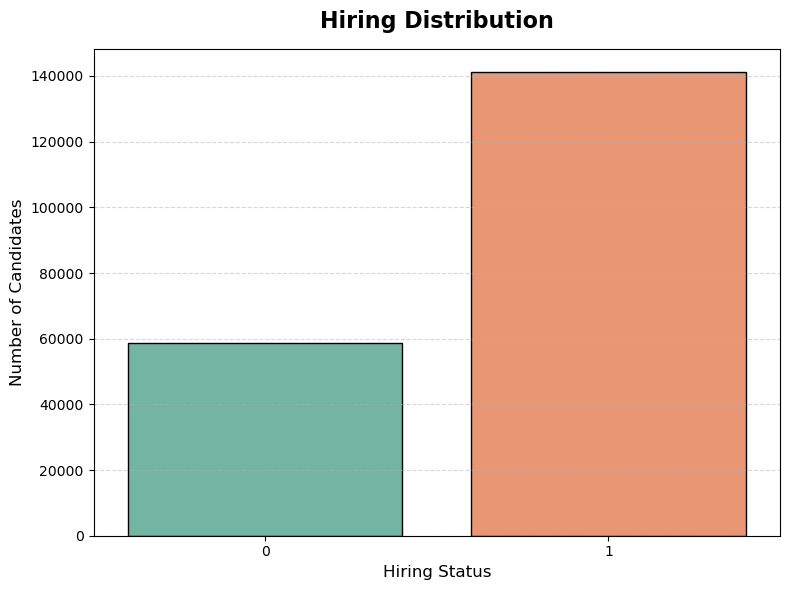

In [25]:
# Hiring Distribution

plt.figure(figsize=(8, 6))
sns.countplot(
    data=df,
    x="hired",palette="Set2",edgecolor="black")

plt.title("Hiring Distribution", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Hiring Status", fontsize=12)
plt.ylabel("Number of Candidates", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(
    r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\AI Resume Screening & Candidate Ranking System\graphs\Hiring Distribution.png",
    dpi=300, bbox_inches="tight")

plt.show()

<h2 style="font-size:30px; color:#374151;">
    <strong>Observation</strong>
</h2>

<p>➦ The number of people who get <strong>hired</strong> is greater than the number of people who <strong>dont</strong>.</p>

<p>➦ Over <span style="background-color:#FEF3C7; padding:2px 6px; border-radius:4px;"><strong>2 Lakhs</strong></span> applicant only <span style="background-color:#DCFCE7; padding:2px 6px; border-radius:4px;"><strong>1.4L</strong></span> candidates got selected.</p>

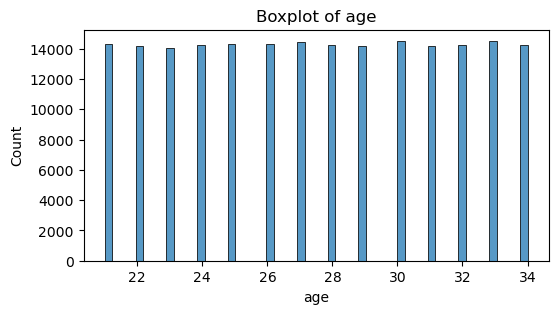

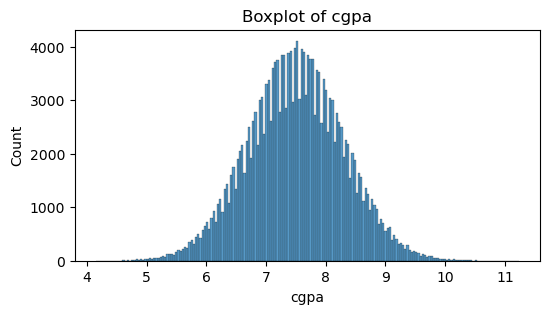

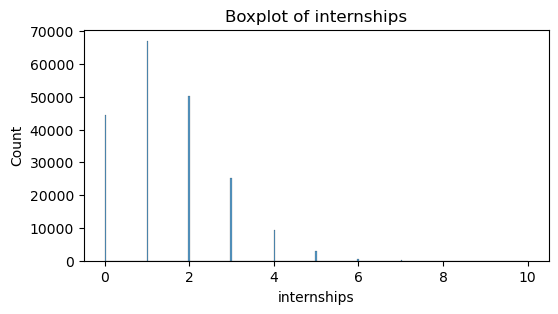

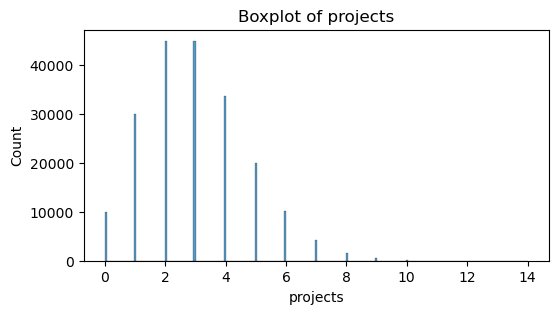

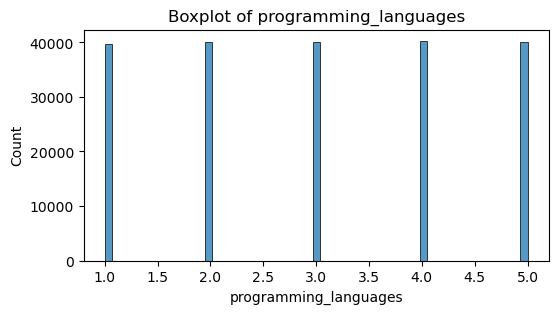

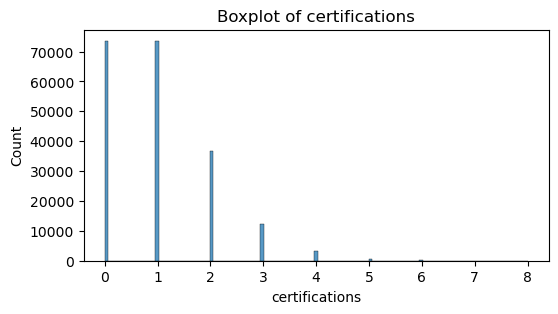

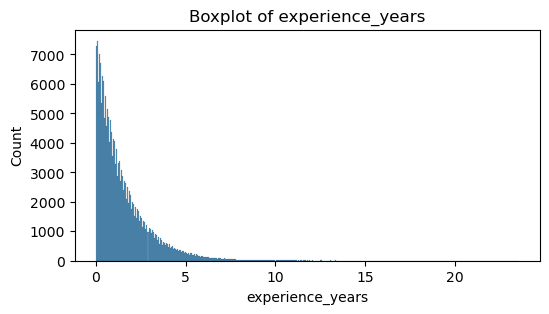

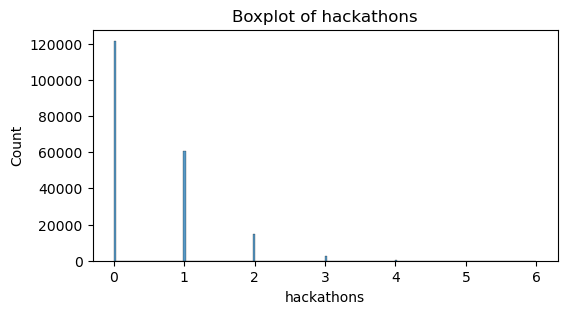

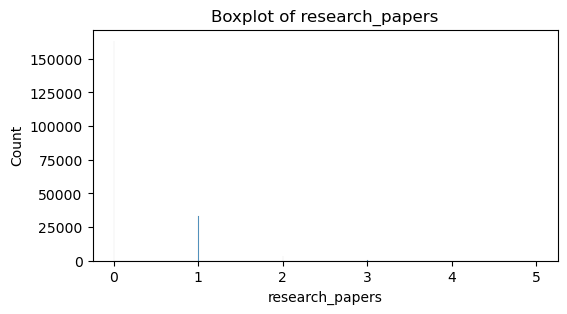

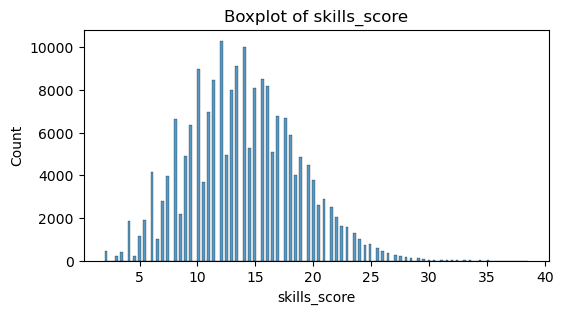

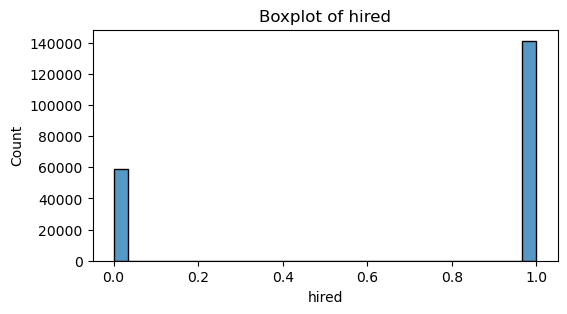

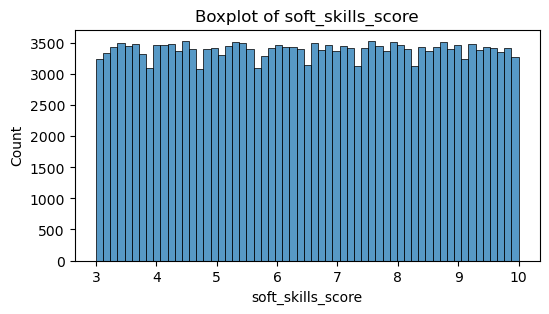

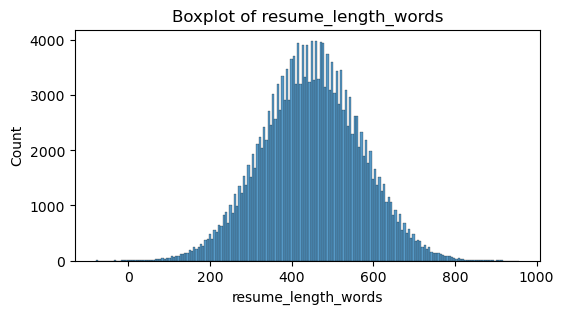

In [27]:
# Histogram to understand the distribution of numerical coloumns

numeric_cols = df.select_dtypes('number').drop(columns=["candidate_id"]).columns

for column in numerical_columns:
    plt.figure(figsize=(6,3))
    sns.histplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

In [ ]:
You're at exactly the right stage. The key is **don't plot every graph you can think of**. Plot graphs that help you understand the data and justify decisions for model building.

For your resume screening dataset, I'd recommend this EDA flow.

---

# 1️⃣ Target Variable Analysis (Start Here)

This is the most important graph.

```python
sns.countplot(x="hired", data=df)
plt.title("Hiring Distribution")
plt.show()
```

### Why?

* Is the dataset balanced?
* Will accuracy be a reliable metric?

**Observation Example**

> The dataset is nearly balanced, indicating that both hired and non-hired candidates are well represented.

---

# 2️⃣ Numerical Feature Distribution

You've already started with Age.

Continue for every numerical feature.

```python
numerical_columns = df.select_dtypes(include="number").drop(columns=["candidate_id"]).columns

for col in numerical_columns:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()
```

### Why?

Understand

* skewness
* spread
* concentration

---

# 3️⃣ Categorical Feature Distribution

For

* education_level
* university_tier
* company_type

```python
categorical_columns = [
    "education_level",
    "university_tier",
    "company_type"
]

for col in categorical_columns:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=20)
    plt.show()
```

### Why?

Understand category frequencies.

---

# 4️⃣ Numerical vs Target ⭐

These are very valuable.

Example

```python
sns.boxplot(x="hired", y="cgpa", data=df)
```

Then

```python
skills_score
experience_years
internships
projects
soft_skills_score
resume_length_words
```

### Why?

These answer questions like:

> Do hired candidates generally have higher CGPA?

---

# 5️⃣ Categorical vs Target

```python
sns.countplot(
    x="education_level",
    hue="hired",
    data=df
)
```

Repeat for

* university_tier
* company_type

### Why?

Shows whether hiring differs across categories.

---

# 6️⃣ Correlation Heatmap

```python
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()
```

### Why?

Find relationships like

* CGPA ↔ Skills
* Projects ↔ Skills
* Experience ↔ Internships

---

# 7️⃣ Scatterplots (Optional)

Choose only meaningful pairs.

Example

```python
sns.scatterplot(
    x="cgpa",
    y="skills_score",
    hue="hired",
    data=df
)
```

Another

```python
sns.scatterplot(
    x="experience_years",
    y="skills_score",
    hue="hired",
    data=df
)
```

---

# 8️⃣ Pairplot (Optional)

If you want one overview

```python
cols = [
    "cgpa",
    "skills_score",
    "experience_years",
    "projects",
    "hired"
]

sns.pairplot(df[cols], hue="hired")
```

Don't use all 17 columns—it becomes unreadable.

---

# A Good EDA Order for This Project

```
EDA
│
├── Target Variable
│   └── Countplot
│
├── Numerical Features
│   └── Histograms
│
├── Categorical Features
│   └── Countplots
│
├── Numerical vs Target
│   └── Boxplots
│
├── Categorical vs Target
│   └── Countplots (hue="hired")
│
├── Correlation
│   └── Heatmap
│
└── Scatterplots (optional)
```

## One suggestion for your notebook 📝

You've already used boxplots in the **Handle Outliers** section. I wouldn't create the same boxplots again in EDA just for repetition.

Instead:

* ✅ Keep **boxplots** in **Handle Outliers** (their purpose there is to detect outliers).
* ✅ In **EDA**, focus on **histograms**, **countplots**, **heatmap**, and **feature vs target** plots that explain the data and the target variable.

This makes your notebook cleaner, avoids duplicate visualizations, and shows that each graph has a distinct purpose in the workflow.
